# Deconvolve the replicating timing for the 10k bin curves using the Haar wavelet for a step-wise result

April 30, 2024

Compute the replicating timing from the deconvolved MNase-seq 10k windows for each gene.

**Goal:** Deconvolve the replication timing such that the result is a step-wise function
from G1 of copy number 1, S-phase (transition from 1 to 2 step-wise), and G2M as copy number 2.


In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()
mnase_analysis_rep1.compute_replication_timing()


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:29.261


In [221]:
mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()
mnase_analysis_rep2.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:43.759


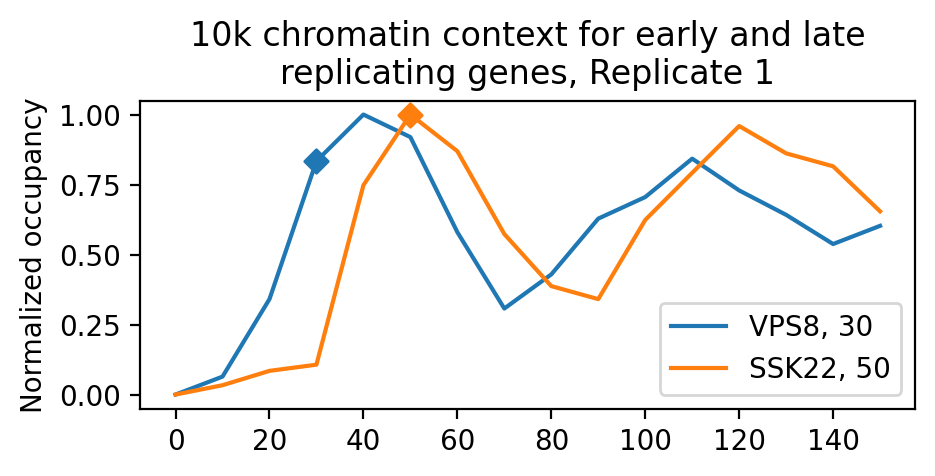

In [6]:
mnase_analysis_rep1.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [236]:
from src.replication_deconvolution_solver import ReplicationChromatinDeconvolveSolver

In [438]:
chrom = 10
solver = ReplicationChromatinDeconvolveSolver(mnase_analysis_rep1, 
                                              mnase_analysis_rep2, wavelet='Haar')
solver.set_chromosome(chrom)
solver.load_combined_config()

In [441]:
solver.define_deconvolution_problem()
_ = solver.solve(gamma_value=0.001, verbose=False)

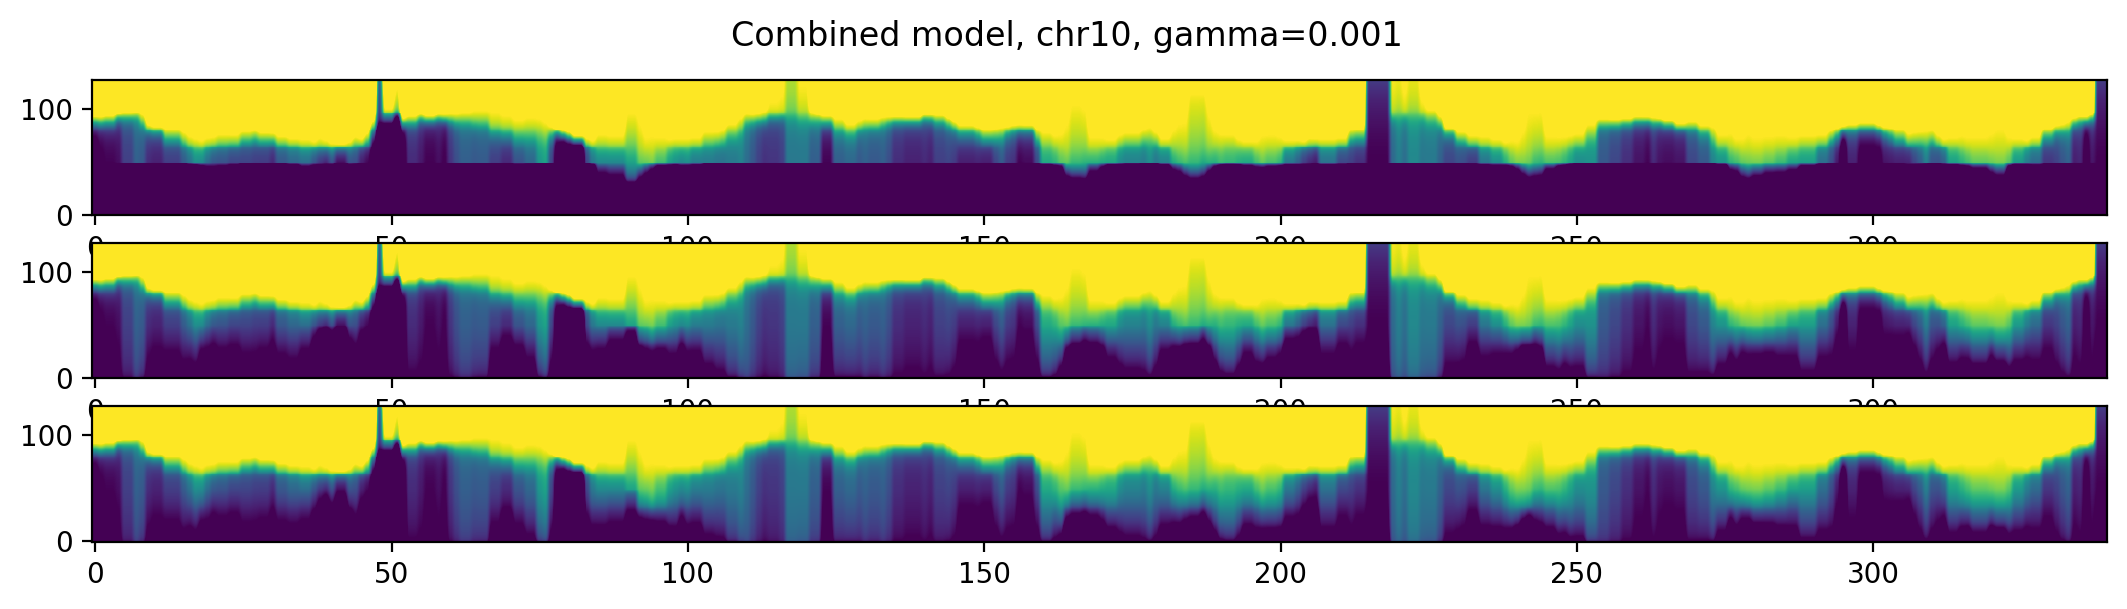

In [442]:
solver.plot_replication_hm(normalize=False, mask=False) # gamma 0.001

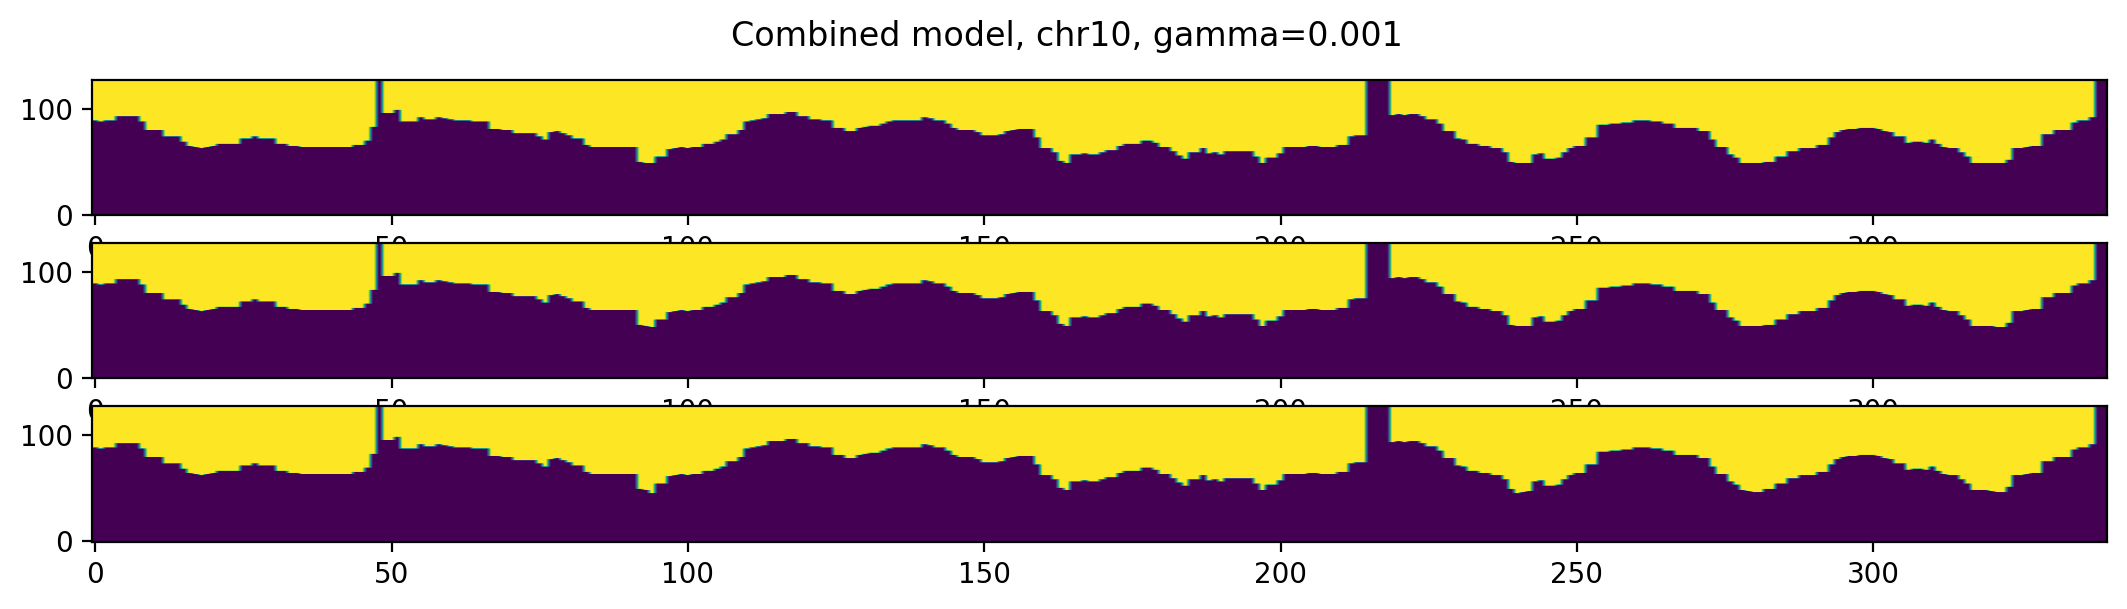

In [443]:
solver.plot_replication_hm(normalize=False, mask=True)

In [451]:
solver.compute_replication_timing()

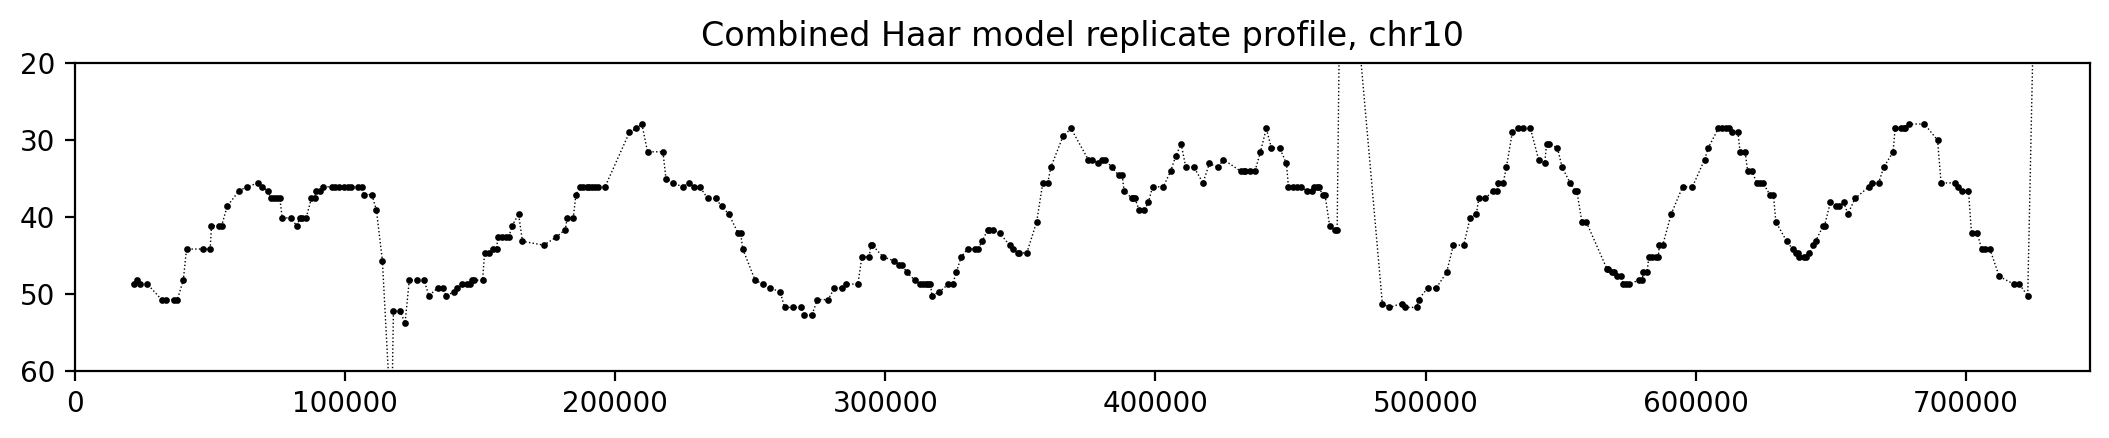

In [452]:
solver.plot_replication_timing()

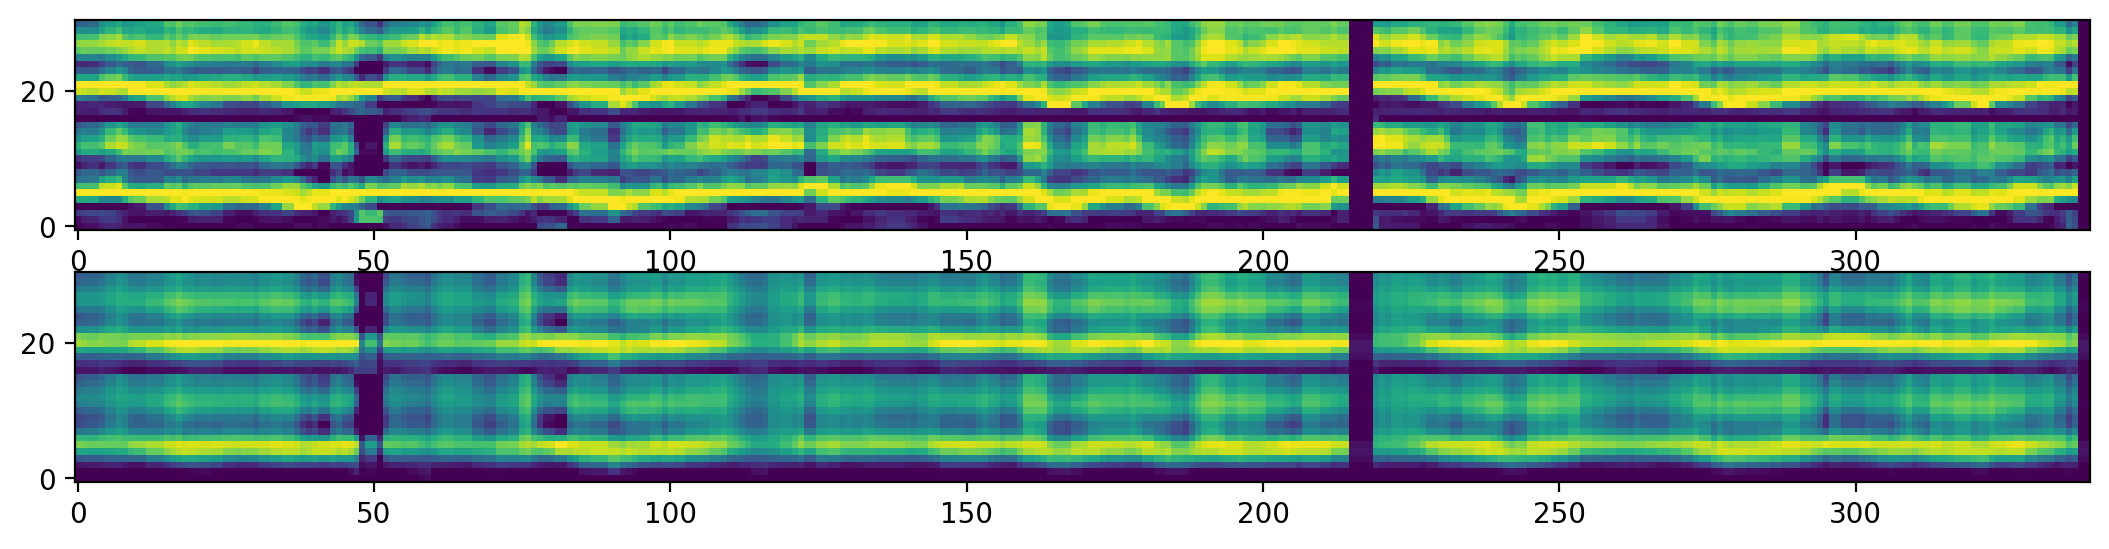

In [453]:
solver.plot_raw_predicted()

In [456]:

from src.timer import Timer

timer = Timer()

for chrom in range(1, 17):
    
    print(f"Chromosome {chrom}...")
    solver = ReplicationChromatinDeconvolveSolver(mnase_analysis_rep1, 
                                                  mnase_analysis_rep2, wavelet='Haar')
    solver.set_chromosome(chrom)
    solver.load_combined_config()
    solver.define_deconvolution_problem()
    solver.solve(gamma_value=0.001, verbose=False)
    solver.compute_replication_timing()
    
    save_dir = 'output/combined_deconv_repl_timing_results_haar/'
    solver.save_results(save_dir)

    timer.print_time()
    

Chromosome 1...
Saved output/combined_deconv_repl_timing_results_haar//chr1_f.npy
Saved output/combined_deconv_repl_timing_results_haar//chr1_repl.csv
00:00:05.192
Chromosome 2...
Saved output/combined_deconv_repl_timing_results_haar//chr2_f.npy
Saved output/combined_deconv_repl_timing_results_haar//chr2_repl.csv
00:00:27.504
Chromosome 3...
Saved output/combined_deconv_repl_timing_results_haar//chr3_f.npy
Saved output/combined_deconv_repl_timing_results_haar//chr3_repl.csv
00:00:35.149
Chromosome 4...
Saved output/combined_deconv_repl_timing_results_haar//chr4_f.npy
Saved output/combined_deconv_repl_timing_results_haar//chr4_repl.csv
00:01:17.833
Chromosome 5...
Saved output/combined_deconv_repl_timing_results_haar//chr5_f.npy
Saved output/combined_deconv_repl_timing_results_haar//chr5_repl.csv
00:01:31.816
Chromosome 6...
Saved output/combined_deconv_repl_timing_results_haar//chr6_f.npy
Saved output/combined_deconv_repl_timing_results_haar//chr6_repl.csv
00:01:37.502
Chromosome 7...


In [ ]:
for chrom in range(1, 17):
        f""
